# DRR Generation (DiffDRR) — Bi-planar AP/LAT X-rays

Render synthetic radiographs (DRRs) from the pre-processed knee CT volumes in
`data/interim/predrr/` to produce one **AP** and one **LAT** view per knee. These DRRs
are the shared input to both decoders in the **3D U-Net vs V-Net** baseline comparison.

**Scope of this notebook:** a *local single-case proof-of-concept* (CPU) to validate the
DiffDRR geometry and output quality before migrating to the Sunway HPC GPU for full batch
processing. The batch loop is included but guarded by `ENV == "HPC"`.

## Input data
256³ NIfTI, 0.78125 mm isotropic, 200 mm FOV, **LPS** orientation, intensity **float [0,1]**
(already bone-windowed at [-450, 1050] HU and normalized), already knee-cropped + split per side.

## Chosen parameters

| Parameter | Value | Note |
|-----------|-------|------|
| Output resolution | 256×256 | 1:1 with the source volume |
| Projection geometry | SDD = 1000 mm, SOD = 850 mm | clinical cone-beam, ~1.18× magnification |
| Detector spacing `delx` | 1.4 mm | full knee in frame with margin (tunable) |
| Output format | 16-bit PNG + float32 `.npy` | PNG for QA, `.npy` lossless model input |
| Intensity | Beer–Lambert (log) → normalize | bone-bright, per-image min-max to [0,1] |

**Note on density:** DiffDRR's `read()` classifies voxels into air/soft-tissue/bone using **HU**
thresholds (-800, 350). Our data is normalized [0,1], so we first reverse the [-450, 1050] HU
windowing back to pseudo-HU; otherwise every voxel is treated as soft tissue and
`bone_attenuation_multiplier` has no effect.

## Output structure
```
data/interim/DRRs/
├── healthy/   VSD_001/{left,right}/{ap,lat}.{png,npy}
└── fractured/ Case1/{left}/{ap,lat}.{png,npy}   # fractured = one side only
```

In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from pathlib import Path
from torchio import ScalarImage
from loguru import logger
from tqdm import tqdm

import diffdrr
from diffdrr.drr import DRR
from diffdrr.data import read

# Pinned: developed against diffdrr 0.6.1. Verify the read()/DRR signatures if this differs.
print("diffdrr", diffdrr.__version__, "| torch", torch.__version__, "| cuda?", torch.cuda.is_available())

diffdrr 0.6.1 | torch 2.10.0+cpu | cuda? False


In [2]:
# ---- Configuration ----
PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
PREDRR_DIR   = PROJECT_ROOT / "data" / "interim" / "predrr"
DRR_OUT_DIR  = PROJECT_ROOT / "data" / "interim" / "DRRs"

# Environment: 'local' (CPU single-case test) or 'HPC' (CUDA batch).
ENV    = "local"
DEVICE = "cpu"
# HPC override: ENV = "HPC"; DEVICE = "cuda"

# Geometry (validated on VSD_001 — see notebook header)
SDD     = 1000.0   # source-to-detector distance (mm)
SOD     = 850.0    # source-to-isocenter distance (mm); magnification = SDD/SOD ~= 1.18x
HEIGHT  = 256
WIDTH   = 256
DELX    = 1.4      # detector pixel spacing (mm); larger = zoom out, smaller = zoom in
DELY    = 1.4

# Density / intensity
HU_WINDOW   = (-450.0, 1050.0)  # the window used during pre-processing; reversed here
BONE_MULT   = 3.0               # bone_attenuation_multiplier: emphasizes bone contrast
MU          = 2.0               # Beer-Lambert attenuation coefficient for post-processing

# AP / LAT poses (Euler angles, degrees, ZXY convention). LAT = +90 deg about superior-inferior axis.
VIEWS = {
    "ap":  {"rotation": [0.0, 0.0, 0.0],  "translation": [0.0, SOD, 0.0]},
    "lat": {"rotation": [90.0, 0.0, 0.0], "translation": [0.0, SOD, 0.0]},
}

DRR_OUT_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"ENV={ENV} DEVICE={DEVICE} | out -> {DRR_OUT_DIR}")

2026-06-17 01:40:01.179 | INFO     | __main__:<module>:31 - ENV=local DEVICE=cpu | out -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\DRRs


In [3]:
def parse_case_side(filename: str):
    """Map a predrr filename to (case_id, side).

    'VSD_001_Left.nii.gz'    -> ('VSD_001', 'left')
    'VSD_z061_Right.nii.gz'  -> ('VSD_z061', 'right')
    'Case3_PartLeft.nii.gz'  -> ('Case3', 'left')
    """
    stem = filename.replace(".nii.gz", "")
    if "_Part" in stem:                      # fractured
        case, sidepart = stem.split("_Part")
        side = "left" if "left" in sidepart.lower() else "right"
    else:                                     # healthy
        case, side_tok = stem.rsplit("_", 1)
        side = side_tok.lower()
    return case, side


def load_subject(nii_path: Path):
    """Load a normalized [0,1] knee volume, reverse the HU windowing, and build a DiffDRR Subject."""
    img = nib.load(str(nii_path))
    arr = img.get_fdata().astype(np.float32)                       # [0,1]
    lo, hi = HU_WINDOW
    hu = arr * (hi - lo) + lo                                       # back to pseudo-HU
    tensor = torch.from_numpy(hu)[None].float()                    # (1, X, Y, Z) channel-first
    si = ScalarImage(tensor=tensor, affine=img.affine)
    return read(si, orientation="AP", bone_attenuation_multiplier=BONE_MULT)

In [4]:
def make_drr(subject):
    """Construct the DiffDRR renderer for a subject."""
    return DRR(subject, sdd=SDD, height=HEIGHT, width=WIDTH, delx=DELX, dely=DELY).to(DEVICE)


def render_view(drr, view: str):
    """Render one view; returns the raw line-integral image as a (H, W) numpy array."""
    cfg = VIEWS[view]
    rot = torch.tensor([cfg["rotation"]], dtype=torch.float32, device=DEVICE)
    trans = torch.tensor([cfg["translation"]], dtype=torch.float32, device=DEVICE)
    out = drr(rot, trans, parameterization="euler_angles", convention="ZXY", degrees=True)
    return out.detach().cpu().numpy()[0, 0]


def postprocess(line_integral: np.ndarray) -> np.ndarray:
    """Beer-Lambert transform -> bone-bright -> per-image min-max normalize to [0,1] (float32)."""
    norm_li = line_integral / (line_integral.max() + 1e-8)
    x = np.exp(-MU * norm_li)        # Beer-Lambert: more attenuation -> darker
    x = 1.0 - x                      # invert so bone (high attenuation) is bright
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x.astype(np.float32)

In [5]:
def save_drr(image01: np.ndarray, dataset: str, case: str, side: str, view: str):
    """Save a normalized [0,1] DRR as 16-bit PNG + float32 .npy. Returns (png_path, npy_path)."""
    out_dir = DRR_OUT_DIR / dataset / case / side
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"{view}.png"
    npy_path = out_dir / f"{view}.npy"
    imageio.imwrite(png_path, (image01 * 65535.0).round().astype(np.uint16))
    np.save(npy_path, image01)
    return png_path, npy_path


def generate_case(nii_path: Path, dataset: str, records: list):
    """Render + save AP and LAT for one knee file. Appends metadata rows to `records`."""
    case, side = parse_case_side(nii_path.name)
    subject = load_subject(nii_path)
    drr = make_drr(subject)
    images = {}
    for view in VIEWS:
        li = render_view(drr, view)
        img01 = postprocess(li)
        png_path, npy_path = save_drr(img01, dataset, case, side, view)
        images[view] = img01
        records.append({
            "case": case, "side": side, "dataset": dataset, "view": view,
            "sdd": SDD, "sod": SOD, "delx": DELX, "height": HEIGHT, "width": WIDTH,
            "bone_mult": BONE_MULT, "mu": MU, "li_max": float(li.max()),
            "png_path": str(png_path), "npy_path": str(npy_path),
        })
    return case, side, images

## Single-case test (local, CPU)

Validate on representative cases before batch processing:
- `VSD_001` (Left + Right) — regular VSD crop path
- `VSD_z061` (Left + Right) — z-prefix full-body-CT crop path (robustness check)
- `Case1_PartLeft`, `Case3_PartLeft` — fractured path (Case3 sources its cast-removed NIfTI; Case8 excluded for metal)

**Check:** bone is bright, the full knee sits in frame with margin, and AP (coronal front) vs
LAT (sagittal side) are clearly distinct anatomical views.

test cases: 100%|██████████| 6/6 [00:52<00:00,  8.70s/it]


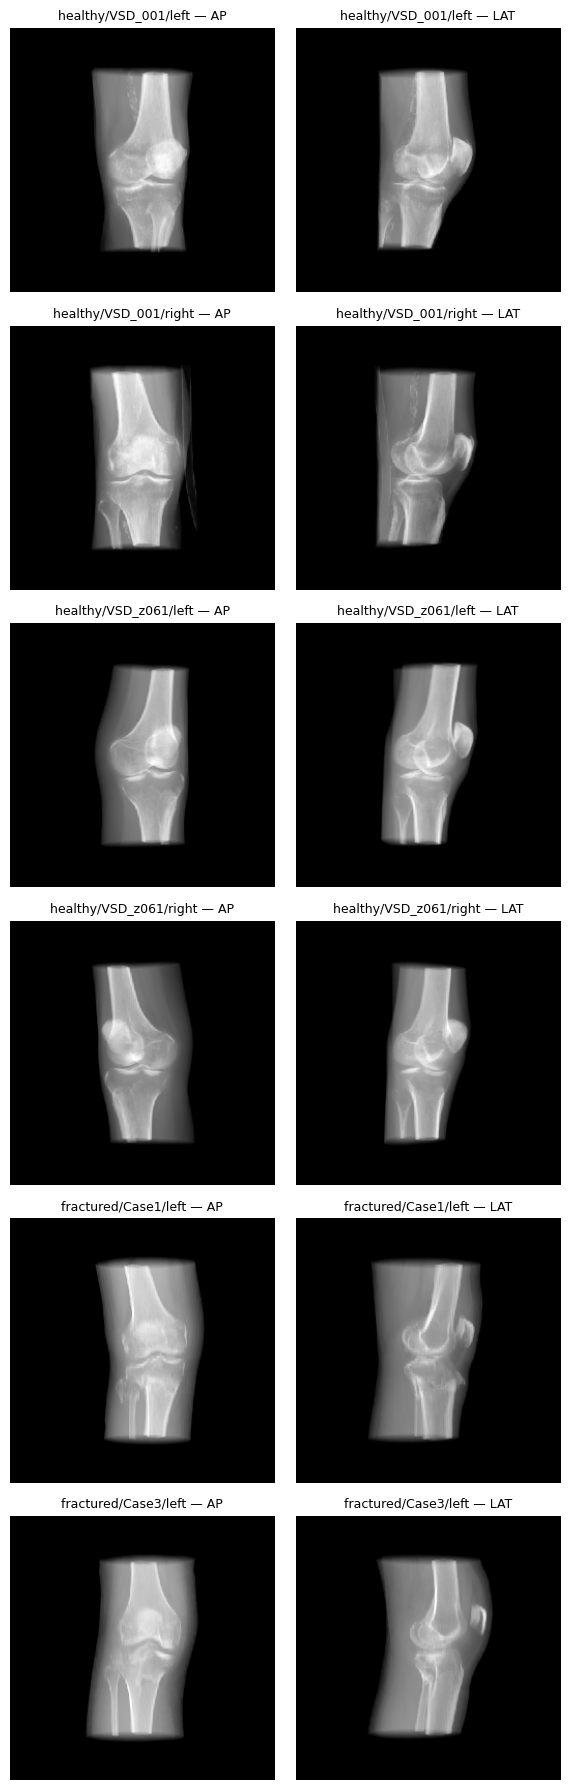

In [6]:
TEST_FILES = [
    ("healthy",   "VSD_001_Left.nii.gz"),
    ("healthy",   "VSD_001_Right.nii.gz"),
    ("healthy",   "VSD_z061_Left.nii.gz"),
    ("healthy",   "VSD_z061_Right.nii.gz"),
    ("fractured", "Case1_PartLeft.nii.gz"),
    ("fractured", "Case3_PartLeft.nii.gz"),  # cast-cleaned via fractured_cast_cleanup.ipynb
]

test_records = []
results = []
for dataset, fname in tqdm(TEST_FILES, desc="test cases"):
    case, side, images = generate_case(PREDRR_DIR / dataset / fname, dataset, test_records)
    results.append((dataset, case, side, images))

# Visual QA: one row per knee, AP and LAT side by side
fig, axes = plt.subplots(len(results), 2, figsize=(6, 3 * len(results)))
for row, (dataset, case, side, images) in enumerate(results):
    for col, view in enumerate(["ap", "lat"]):
        ax = axes[row, col]
        ax.imshow(images[view], cmap="gray")
        ax.set_title(f"{dataset}/{case}/{side} — {view.upper()}", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# Sanity check: dtype / shape / range of the saved outputs for the first test case
_d, _c, _s, _ = results[0]
_npy = DRR_OUT_DIR / _d / _c / _s / "ap.npy"
_png = DRR_OUT_DIR / _d / _c / _s / "ap.png"
_a = np.load(_npy); _p = imageio.imread(_png)
print(f".npy  {_npy.name}: dtype={_a.dtype} shape={_a.shape} range=[{_a.min():.3f}, {_a.max():.3f}]")
print(f".png  {_png.name}: dtype={_p.dtype} shape={_p.shape} range=[{_p.min()}, {_p.max()}]")

.npy  ap.npy: dtype=float32 shape=(256, 256) range=[0.000, 1.000]
.png  ap.png: dtype=uint16 shape=(256, 256) range=[0, 65535]


Found 6 cases total: 4 healthy, 2 fractured


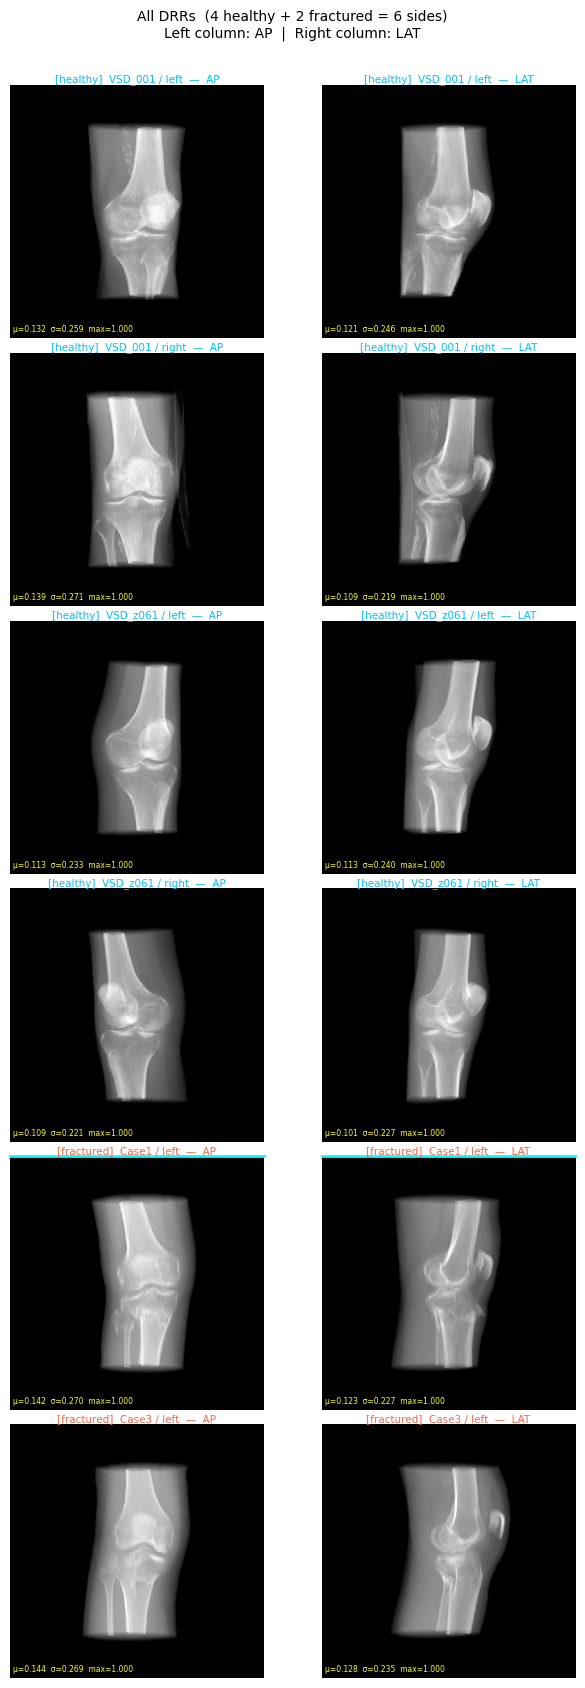

Saved → c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\DRRs\visual_inspection_all.png
No anomalies detected in any DRR.


,dataset,case,side,view,mean,std,min,max,flag
0,healthy,VSD_001,left,ap,0.1316,0.2590,0.0,1.0,
1,healthy,VSD_001,left,lat,0.1210,0.2464,0.0,1.0,
2,healthy,VSD_001,right,ap,0.1391,0.2705,0.0,1.0,
3,healthy,VSD_001,right,lat,0.1094,0.2187,0.0,1.0,
4,healthy,VSD_z061,left,ap,0.1131,0.2330,0.0,1.0,
5,healthy,VSD_z061,left,lat,0.1134,0.2401,0.0,1.0,
6,healthy,VSD_z061,right,ap,0.1087,0.2206,0.0,1.0,
7,healthy,VSD_z061,right,lat,0.1007,0.2273,0.0,1.0,
8,fractured,Case1,left,ap,0.1424,0.2698,0.0,1.0,
9,fractured,Case1,left,lat,0.1234,0.2270,0.0,1.0,


In [8]:
def collect_all_drr_cases(drr_dir: Path):
    """Return all (dataset, case, side) tuples that have both ap.npy and lat.npy, sorted."""
    cases = []
    for dataset in ["healthy", "fractured"]:
        dset_dir = drr_dir / dataset
        if not dset_dir.exists():
            continue
        for case_dir in sorted(dset_dir.iterdir()):
            if not case_dir.is_dir():
                continue
            for side_dir in sorted(case_dir.iterdir()):
                if not side_dir.is_dir():
                    continue
                if (side_dir / "ap.npy").exists() and (side_dir / "lat.npy").exists():
                    cases.append((dataset, case_dir.name, side_dir.name))
    return cases

all_cases = collect_all_drr_cases(DRR_OUT_DIR)
n_healthy = sum(1 for d, _, _ in all_cases if d == "healthy")
n_frac    = sum(1 for d, _, _ in all_cases if d == "fractured")
print(f"Found {len(all_cases)} cases total: {n_healthy} healthy, {n_frac} fractured")

# --- Full image grid: one row per (dataset, case, side), left=AP, right=LAT ---
ROW_H = 2.8   # inches per row; increase if titles overlap
fig, axes = plt.subplots(len(all_cases), 2, figsize=(7, ROW_H * len(all_cases)))
axes = np.array(axes) if len(all_cases) > 1 else np.array(axes)[None]

LABEL_COLOR = {"healthy": "deepskyblue", "fractured": "tomato"}
prev_dataset = None

for row, (dataset, case, side) in enumerate(all_cases):
    # Draw a cyan separator line at the first fractured row
    if dataset != prev_dataset and prev_dataset is not None:
        for col in range(2):
            axes[row, col].axhline(y=-1, color="cyan", linewidth=2, clip_on=False)
    prev_dataset = dataset

    for col, view in enumerate(["ap", "lat"]):
        img = np.load(DRR_OUT_DIR / dataset / case / side / f"{view}.npy")
        ax = axes[row, col]
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(
            f"[{dataset}]  {case} / {side}  —  {view.upper()}",
            fontsize=7.5, color=LABEL_COLOR[dataset], pad=2
        )
        ax.axis("off")
        # Per-image stats in bottom-left corner
        ax.text(
            3, img.shape[0] - 5,
            f"μ={img.mean():.3f}  σ={img.std():.3f}  max={img.max():.3f}",
            fontsize=5.5, color="yellow", va="bottom"
        )

plt.suptitle(
    f"All DRRs  ({n_healthy} healthy + {n_frac} fractured = {len(all_cases)} sides)\n"
    "Left column: AP  |  Right column: LAT",
    fontsize=10, y=1.002
)
plt.tight_layout(h_pad=0.25)
out_path = DRR_OUT_DIR / "visual_inspection_all.png"
plt.savefig(str(out_path), dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

# --- Stats table with anomaly flags ---
stat_rows = []
for dataset, case, side in all_cases:
    for view in ["ap", "lat"]:
        img = np.load(DRR_OUT_DIR / dataset / case / side / f"{view}.npy")
        flags = []
        if img.max() < 0.3:   flags.append("LOW_MAX")
        if img.mean() < 0.05: flags.append("LOW_MEAN")
        if img.min() == img.max(): flags.append("FLAT")
        stat_rows.append({
            "dataset": dataset, "case": case, "side": side, "view": view,
            "mean": round(float(img.mean()), 4),
            "std":  round(float(img.std()),  4),
            "min":  round(float(img.min()),  4),
            "max":  round(float(img.max()),  4),
            "flag": " ".join(flags),
        })

stats_df = pd.DataFrame(stat_rows)
flagged = stats_df[stats_df["flag"] != ""]
if flagged.empty:
    print("No anomalies detected in any DRR.")
else:
    print(f"Flagged cases ({len(flagged)}):")
    display(flagged)

display(stats_df)

## Batch processing (HPC)

Once the single-case output looks correct, run this on the Sunway HPC GPU. Set `ENV = "HPC"`
and `DEVICE = "cuda"` in the config cell first. Guarded so it is a no-op during local testing.

In [ ]:
if ENV == "HPC":
    batch_records = []
    for dataset in ["healthy", "fractured"]:
        files = sorted((PREDRR_DIR / dataset).glob("*.nii.gz"))
        for nii_path in tqdm(files, desc=f"DRR {dataset}"):
            generate_case(nii_path, dataset, batch_records)
    pd.DataFrame(batch_records).to_csv(DRR_OUT_DIR / "drr_generation_metadata.csv", index=False)
    logger.info(f"Batch complete: {len(batch_records)} DRRs across healthy + fractured")
else:
    logger.info("ENV != 'HPC' — skipping batch loop (local single-case test only)")

In [ ]:
# Export metadata for the test run (local). On HPC the batch cell writes the full CSV.
df = pd.DataFrame(test_records)
df.to_csv(DRR_OUT_DIR / "drr_generation_test_metadata.csv", index=False)
df